# TDMA Multi-User Preparation

This notebook keeps the TDMA exploration logic local to the notebook. It declares the user scenario,
builds each user's feasible active-state set with the shared single-user engine, then searches the
joint TDMA schedule and visualizes the result. Shared config and PA-domain objects come from
`src/radio_core`, while downlink path loss and the single-user engine come from
`src/downlink_resource_allocation`.


## 1. Imports


In [1]:
import os
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors, patches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
from IPython.display import display
sys.path.append(str((Path.cwd() / "src").resolve()))

from radio_core import (
    MULTI_USER_TDMA_PRESET,
    PAState,
    PASwitchPolicy,
    build_model_inputs,
    build_multi_user_runtime_cfg,
    build_multi_user_system_cfg,
    build_pa_catalog,
    build_pa_characteristics_table,
    inactive_pa_bank_power,
)
from downlink_resource_allocation import PathLossModel, SingleUserResourceAllocationEngine


In [ ]:
# Coarse multi-user TDMA helpers are kept local to this notebook for now.
_TEMP_ALPHA_ON_WINDOW = "metric_alpha_on_window"
_TEMP_ALPHA_FRAME = "metric_alpha_frame"
_TEMP_RATE_AVG_ON_WINDOW_BPS = "metric_rate_avg_on_window_bps"
_TEMP_RATE_AVG_FRAME_BPS = "metric_rate_avg_frame_bps"
_TEMP_P_DC_ACTIVE_AVG_FRAME_W = "metric_p_dc_active_avg_frame_w"
_TEMP_P_RF_OUT_AVG_FRAME_W = "metric_p_rf_out_avg_frame_w"
_TEMP_SCHEDULE_SORT_COST = "metric_schedule_sort_cost"
_TEMP_COLUMNS = {
    _TEMP_ALPHA_ON_WINDOW,
    _TEMP_ALPHA_FRAME,
    _TEMP_RATE_AVG_ON_WINDOW_BPS,
    _TEMP_RATE_AVG_FRAME_BPS,
    _TEMP_P_DC_ACTIVE_AVG_FRAME_W,
    _TEMP_P_RF_OUT_AVG_FRAME_W,
    _TEMP_SCHEDULE_SORT_COST,
}


def row_active_on_window_share(row):
    return float(row["n_slots"]) / float(row["sequence_on_window_slots"])


def row_active_frame_share(row):
    return float(row["n_slots"]) / float(row["sequence_frame_slots"])


def row_rate_avg_on_window_bps(row):
    return row_active_on_window_share(row) * float(row["rate_active_bps"])


def row_rate_avg_frame_bps(row):
    return row_active_frame_share(row) * float(row["rate_active_bps"])


def row_p_dc_active_avg_frame_w(row):
    return row_active_frame_share(row) * float(row["p_dc_active_w"])


def row_p_rf_out_avg_frame_w(row):
    return row_active_frame_share(row) * float(row["p_rf_out_active_w"])


def row_schedule_sort_cost(row, pa_catalog, n_tx_chains, switch_policy):
    switch_policy = _coerce_switch_policy(switch_policy)
    return row_incremental_schedule_cost(
        row,
        used_pa_ids=frozenset(),
        pa_catalog=pa_catalog,
        n_tx_chains=n_tx_chains,
        switch_policy=switch_policy,
    )


def row_incremental_schedule_cost(row, used_pa_ids, pa_catalog, n_tx_chains, switch_policy):
    switch_policy = _coerce_switch_policy(switch_policy)
    active_cost = row_p_dc_active_avg_frame_w(row)
    if switch_policy == PASwitchPolicy.HARD_OFF:
        return float(active_cost)

    pa_id = int(row["pa_id"])
    idle_bank_w = inactive_pa_bank_power(
        pa_catalog[pa_id],
        PAState.IDLE,
        n_tx_chains,
    )
    active_share = row_active_frame_share(row)
    incremental_cost = active_cost - active_share * idle_bank_w
    if pa_id not in used_pa_ids:
        incremental_cost += idle_bank_w
    return float(incremental_cost)


def _drop_temp_columns(df):
    return df.drop(columns=[col for col in _TEMP_COLUMNS if col in df.columns], errors="ignore")


def _with_derived_metrics(df):
    if df.empty:
        return df.copy()

    out = df.copy()
    n_slots = out["n_slots"].astype(float)
    sequence_on_window_slots = out["sequence_on_window_slots"].astype(float)
    sequence_frame_slots = out["sequence_frame_slots"].astype(float)
    rate_active_bps = out["rate_active_bps"].astype(float)
    p_dc_active_w = out["p_dc_active_w"].astype(float)
    p_rf_out_active_w = out["p_rf_out_active_w"].astype(float)

    out[_TEMP_ALPHA_ON_WINDOW] = n_slots / np.clip(sequence_on_window_slots, 1e-30, None)
    out[_TEMP_ALPHA_FRAME] = n_slots / np.clip(sequence_frame_slots, 1e-30, None)
    out[_TEMP_RATE_AVG_ON_WINDOW_BPS] = out[_TEMP_ALPHA_ON_WINDOW] * rate_active_bps
    out[_TEMP_RATE_AVG_FRAME_BPS] = out[_TEMP_ALPHA_FRAME] * rate_active_bps
    out[_TEMP_P_DC_ACTIVE_AVG_FRAME_W] = out[_TEMP_ALPHA_FRAME] * p_dc_active_w
    out[_TEMP_P_RF_OUT_AVG_FRAME_W] = out[_TEMP_ALPHA_FRAME] * p_rf_out_active_w
    return out


def _resolve_metric_column(df, requested_col, derived_col):
    return requested_col if requested_col in df.columns else derived_col


def _coerce_switch_policy(switch_policy):
    if isinstance(switch_policy, PASwitchPolicy):
        return switch_policy
    return PASwitchPolicy(str(switch_policy))


def build_feasible_configs_from_active_table(
    user_cfg,
    active_df,
    total_slots,
    dl_slots_per_window,
    frame_slots_per_window,
    feasible_config_columns,
    pa_catalog=None,
    n_tx_chains=None,
):
    """Map active-state PHY rows into minimum-slot TDMA rows for one repeat sequence."""
    del pa_catalog, n_tx_chains

    total_slots = int(total_slots)
    dl_slots_per_window = int(dl_slots_per_window)
    frame_slots_per_window = int(frame_slots_per_window)
    if total_slots <= 0:
        raise ValueError("total_slots must be positive.")
    if dl_slots_per_window <= 0 or frame_slots_per_window <= 0:
        raise ValueError("dl_slots_per_window and frame_slots_per_window must be positive.")
    if total_slots % dl_slots_per_window != 0:
        raise ValueError("total_slots must be an integer multiple of dl_slots_per_window.")
    if active_df is None or active_df.empty:
        return pd.DataFrame(columns=list(feasible_config_columns))

    schedule_windows = total_slots // dl_slots_per_window
    frame_total_slots = schedule_windows * frame_slots_per_window

    rate_target_bps = float(user_cfg["rate_target_bps"])
    rate_active = active_df["rate_ach_bps"].astype(float).to_numpy()
    slots_exact = frame_total_slots * rate_target_bps / np.clip(rate_active, 1e-30, None)
    slots_required = np.ceil(slots_exact - 1e-12).astype(int)
    feasible_mask = np.isfinite(slots_exact) & (rate_active > 0.0) & (slots_required >= 1) & (slots_required <= total_slots)
    if not np.any(feasible_mask):
        return pd.DataFrame(columns=list(feasible_config_columns))

    feasible_df = active_df.loc[feasible_mask].copy().reset_index(drop=True)
    feasible_df["user_id"] = int(user_cfg["user_id"])
    feasible_df["n_slots"] = slots_required[feasible_mask]
    feasible_df["schedule_windows"] = int(schedule_windows)
    feasible_df["sequence_on_window_slots"] = int(total_slots)
    feasible_df["sequence_frame_slots"] = int(frame_total_slots)
    feasible_df["prbs"] = feasible_df["n_prb"].astype(int)
    feasible_df["active_tx_chains"] = feasible_df["n_active_tx"].astype(int)
    feasible_df["rate_active_bps"] = feasible_df["rate_ach_bps"].astype(float)
    if "p_rf_out_active_w" in feasible_df.columns:
        feasible_df["p_rf_out_active_w"] = feasible_df["p_rf_out_active_w"].astype(float)
    elif "p_out_total_w" in feasible_df.columns:
        feasible_df["p_rf_out_active_w"] = feasible_df["p_out_total_w"].astype(float)
    elif "p_sig_out_total_w" in feasible_df.columns:
        feasible_df["p_rf_out_active_w"] = feasible_df["p_sig_out_total_w"].astype(float)
    else:
        feasible_df["p_rf_out_active_w"] = np.nan

    sort_ready = _with_derived_metrics(feasible_df)
    sort_ready = sort_ready.sort_values(
        ["n_slots", _TEMP_P_DC_ACTIVE_AVG_FRAME_W, _TEMP_RATE_AVG_FRAME_BPS, "prbs", "mcs"],
        ascending=[True, True, False, True, True],
    ).reset_index(drop=True)
    return _drop_temp_columns(sort_ready)[list(feasible_config_columns)].reset_index(drop=True)


def prune_dominated_configs(df, rate_col="rate_avg_bps", power_col="p_dc_avg_w", group_cols=("user_id",)):
    """Keep only the non-dominated rate-power frontier inside each group."""
    if df.empty:
        return df.copy()

    working = _with_derived_metrics(df)
    resolved_rate_col = _resolve_metric_column(working, rate_col, _TEMP_RATE_AVG_FRAME_BPS)
    resolved_power_col = _resolve_metric_column(working, power_col, _TEMP_P_DC_ACTIVE_AVG_FRAME_W)

    pruned_groups = []
    for _, group in working.groupby(list(group_cols), dropna=False, sort=False):
        ranked = group.sort_values([resolved_power_col, resolved_rate_col], ascending=[True, False]).reset_index(drop=True)
        keep_rows = []
        best_rate_so_far = -np.inf

        for row in ranked.itertuples(index=False):
            rate_value = float(getattr(row, resolved_rate_col))
            if rate_value > best_rate_so_far + 1e-9:
                keep_rows.append(row._asdict())
                best_rate_so_far = rate_value

        pruned_groups.append(pd.DataFrame(keep_rows))

    result = pd.concat(pruned_groups, ignore_index=True).sort_values(
        ["user_id", _TEMP_ALPHA_ON_WINDOW, resolved_power_col, resolved_rate_col],
        ascending=[True, True, True, False],
    ).reset_index(drop=True)
    return _drop_temp_columns(result)


def limit_user_config_count(df, max_configs_per_user=None):
    if max_configs_per_user is None or df.empty or len(df) <= int(max_configs_per_user):
        return df.copy()

    working = _with_derived_metrics(df)
    limited = (
        working.sort_values(
            [_TEMP_P_DC_ACTIVE_AVG_FRAME_W, _TEMP_ALPHA_ON_WINDOW, _TEMP_RATE_AVG_FRAME_BPS],
            ascending=[True, True, False],
        )
        .head(int(max_configs_per_user))
        .reset_index(drop=True)
    )
    return _drop_temp_columns(limited)


def schedule_rank(schedule_p_dc_total_avg_frame_w, slot_total, total_rate_bps):
    return (float(schedule_p_dc_total_avg_frame_w), int(slot_total), -float(total_rate_bps))


def evaluate_schedule_rows(selected_rows, total_slots, frame_total_slots, pa_catalog, n_tx_chains, switch_policy):
    switch_policy = _coerce_switch_policy(switch_policy)
    inactive_state = PAState.IDLE if switch_policy == PASwitchPolicy.STANDBY else PAState.OFF

    slot_total = int(sum(int(row["n_slots"]) for row in selected_rows))
    alpha_total = float(slot_total) / float(total_slots)
    alpha_total_frame = float(slot_total) / float(frame_total_slots)
    total_rate_bps = float(sum(row_rate_avg_frame_bps(row) for row in selected_rows))
    schedule_p_rf_out_total_avg_frame_w = float(sum(row_p_rf_out_avg_frame_w(row) for row in selected_rows))

    pa_summaries = []
    schedule_p_dc_total_avg_frame_w = 0.0
    used_pa_ids = sorted({int(row["pa_id"]) for row in selected_rows})
    for pa_id in used_pa_ids:
        pa_rows = [row for row in selected_rows if int(row["pa_id"]) == pa_id]
        pa_alpha_frame = float(sum(row_active_frame_share(row) for row in pa_rows))
        pa_alpha_frame = float(np.clip(pa_alpha_frame, 0.0, 1.0))
        pa_p_dc_active_avg_frame_w = float(sum(row_p_dc_active_avg_frame_w(row) for row in pa_rows))
        inactive_bank_w = float(inactive_pa_bank_power(pa_catalog[pa_id], inactive_state, n_tx_chains))
        pa_p_dc_inactive_avg_frame_w = float((1.0 - pa_alpha_frame) * inactive_bank_w)
        pa_p_dc_total_avg_frame_w = float(pa_p_dc_active_avg_frame_w + pa_p_dc_inactive_avg_frame_w)
        schedule_p_dc_total_avg_frame_w += pa_p_dc_total_avg_frame_w
        pa_summaries.append(
            {
                "pa_id": int(pa_id),
                "pa_name": str(pa_rows[0]["pa_name"]),
                "pa_alpha_frame": float(pa_alpha_frame),
                "pa_inactive_state": inactive_state.value,
                "pa_p_dc_active_avg_frame_w": float(pa_p_dc_active_avg_frame_w),
                "pa_p_dc_inactive_avg_frame_w": float(pa_p_dc_inactive_avg_frame_w),
                "pa_p_dc_total_avg_frame_w": float(pa_p_dc_total_avg_frame_w),
            }
        )

    return {
        "rows": sorted([dict(row) for row in selected_rows], key=lambda row: int(row["user_id"])),
        "slot_total": int(slot_total),
        "alpha_total": float(alpha_total),
        "alpha_total_frame": float(alpha_total_frame),
        "unused_slots": int(total_slots - slot_total),
        "unused_time": float(1.0 - alpha_total_frame),
        "total_rate_bps": float(total_rate_bps),
        "schedule_p_dc_total_avg_frame_w": float(schedule_p_dc_total_avg_frame_w),
        "schedule_p_rf_out_total_avg_frame_w": float(schedule_p_rf_out_total_avg_frame_w),
        "pa_summaries": pa_summaries,
        "switch_policy": switch_policy.value,
    }


def _joint_candidate_row(schedule_result, schedule_id):
    return {
        "schedule_id": int(schedule_id),
        "slot_total": int(schedule_result["slot_total"]),
        "alpha_total": float(schedule_result["alpha_total"]),
        "alpha_total_frame": float(schedule_result["alpha_total_frame"]),
        "unused_slots": int(schedule_result["unused_slots"]),
        "unused_time": float(schedule_result["unused_time"]),
        "total_rate_bps": float(schedule_result["total_rate_bps"]),
        "schedule_p_dc_total_avg_frame_w": float(schedule_result["schedule_p_dc_total_avg_frame_w"]),
        "schedule_p_rf_out_total_avg_frame_w": float(schedule_result["schedule_p_rf_out_total_avg_frame_w"]),
        "switch_policy": str(schedule_result["switch_policy"]),
    }


def search_multi_user_tdma_schedules(
    user_feasible_sets,
    total_slots,
    frame_total_slots=None,
    pa_catalog=None,
    n_tx_chains=None,
    switch_policy=PASwitchPolicy.STANDBY,
):
    """Search the TDMA configuration space with depth-first branch-and-bound."""
    tol = 1e-12
    total_slots = int(total_slots)
    frame_total_slots = int(frame_total_slots if frame_total_slots is not None else total_slots)
    if pa_catalog is None or n_tx_chains is None:
        raise ValueError("pa_catalog and n_tx_chains are required for schedule evaluation.")

    switch_policy = _coerce_switch_policy(switch_policy)
    user_ids = list(user_feasible_sets.keys())

    search_ready_sets = {}
    min_slots = {}
    min_sort_cost = {}
    for user_id in user_ids:
        df_sorted = _with_derived_metrics(user_feasible_sets[user_id])
        df_sorted[_TEMP_SCHEDULE_SORT_COST] = [
            row_schedule_sort_cost(row, pa_catalog=pa_catalog, n_tx_chains=n_tx_chains, switch_policy=switch_policy)
            for row in df_sorted.to_dict("records")
        ]
        df_sorted = df_sorted.sort_values(
            [_TEMP_SCHEDULE_SORT_COST, _TEMP_P_DC_ACTIVE_AVG_FRAME_W, "n_slots", _TEMP_RATE_AVG_FRAME_BPS],
            ascending=[True, True, True, False],
        ).reset_index(drop=True)
        search_ready_sets[user_id] = _drop_temp_columns(df_sorted)
        min_slots[user_id] = int(df_sorted["n_slots"].min())
        min_sort_cost[user_id] = float(df_sorted[_TEMP_SCHEDULE_SORT_COST].min())

    user_order = sorted(
        user_ids,
        key=lambda user_id: (min_slots[user_id], min_sort_cost[user_id]),
        reverse=True,
    )
    user_rows = {user_id: search_ready_sets[user_id].to_dict("records") for user_id in user_order}

    suffix_min_slots = [0] * (len(user_order) + 1)
    for depth in range(len(user_order) - 1, -1, -1):
        user_id = user_order[depth]
        suffix_min_slots[depth] = suffix_min_slots[depth + 1] + min_slots[user_id]

    max_rate_avg_frame_bps = {
        user_id: max((row_rate_avg_frame_bps(row) for row in user_rows[user_id]), default=0.0)
        for user_id in user_order
    }
    suffix_max_rate_avg_frame_bps = [0.0] * (len(user_order) + 1)
    for depth in range(len(user_order) - 1, -1, -1):
        user_id = user_order[depth]
        suffix_max_rate_avg_frame_bps[depth] = (
            suffix_max_rate_avg_frame_bps[depth + 1] + max_rate_avg_frame_bps[user_id]
        )

    search_stats = {
        "user_order": list(user_order),
        "nodes_visited": 0,
        "complete_feasible_schedules": 0,
        "pruned_time_direct": 0,
        "pruned_power_direct": 0,
        "pruned_time_bound": 0,
        "pruned_power_bound": 0,
        "pruned_rank_bound": 0,
        "best_updates": 0,
    }
    joint_candidates = []
    best_rank = (np.inf, np.inf, np.inf)
    best_schedule_power = np.inf
    best_schedule = None
    lower_bound_cache = {}

    def remaining_cost_lower_bound(depth, used_pa_ids):
        if depth >= len(user_order):
            return 0.0

        key = (int(depth), tuple(sorted(int(pa_id) for pa_id in used_pa_ids)))
        cached = lower_bound_cache.get(key)
        if cached is not None:
            return cached

        user_id = user_order[depth]
        best_remaining_cost = np.inf
        for row in user_rows[user_id]:
            next_used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])})
            candidate_cost = row_incremental_schedule_cost(
                row,
                used_pa_ids=used_pa_ids,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            ) + remaining_cost_lower_bound(depth + 1, next_used_pa_ids)
            if candidate_cost < best_remaining_cost:
                best_remaining_cost = candidate_cost

        lower_bound_cache[key] = float(best_remaining_cost)
        return float(best_remaining_cost)

    def seed_greedy_schedule():
        slot_sum = 0
        selected_rows = []
        used_pa_ids = frozenset()
        for depth, user_id in enumerate(user_order):
            remaining_slots_lb = suffix_min_slots[depth + 1]
            selected_row = None
            ranked_rows = sorted(
                user_rows[user_id],
                key=lambda row: (
                    row_incremental_schedule_cost(
                        row,
                        used_pa_ids=used_pa_ids,
                        pa_catalog=pa_catalog,
                        n_tx_chains=n_tx_chains,
                        switch_policy=switch_policy,
                    ),
                    int(row["n_slots"]),
                    -row_rate_avg_frame_bps(row),
                ),
            )
            for row in ranked_rows:
                next_slot_sum = int(slot_sum + int(row["n_slots"]))
                if next_slot_sum + remaining_slots_lb <= total_slots:
                    selected_row = row
                    slot_sum = next_slot_sum
                    selected_rows.append(row)
                    used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])})
                    break
            if selected_row is None:
                return None

        return evaluate_schedule_rows(
            selected_rows=selected_rows,
            total_slots=total_slots,
            frame_total_slots=frame_total_slots,
            pa_catalog=pa_catalog,
            n_tx_chains=n_tx_chains,
            switch_policy=switch_policy,
        )

    def dfs(depth, slot_sum, exact_cost_sum, rate_sum, used_pa_ids, selected_rows):
        nonlocal best_rank, best_schedule_power, best_schedule

        search_stats["nodes_visited"] += 1

        if depth == len(user_order):
            schedule_result = evaluate_schedule_rows(
                selected_rows=selected_rows,
                total_slots=total_slots,
                frame_total_slots=frame_total_slots,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            )
            schedule_id = len(joint_candidates) + 1
            joint_candidates.append(_joint_candidate_row(schedule_result, schedule_id=schedule_id))
            search_stats["complete_feasible_schedules"] += 1

            candidate_rank = schedule_rank(
                schedule_result["schedule_p_dc_total_avg_frame_w"],
                schedule_result["slot_total"],
                schedule_result["total_rate_bps"],
            )
            if candidate_rank < best_rank:
                best_rank = candidate_rank
                best_schedule_power = float(schedule_result["schedule_p_dc_total_avg_frame_w"])
                best_schedule = schedule_result
                search_stats["best_updates"] += 1
            return

        user_id = user_order[depth]
        for row in user_rows[user_id]:
            next_slot_sum = int(slot_sum + int(row["n_slots"]))
            if next_slot_sum > total_slots:
                search_stats["pruned_time_direct"] += 1
                continue

            row_rate_value = row_rate_avg_frame_bps(row)
            next_exact_cost_sum = float(
                exact_cost_sum
                + row_incremental_schedule_cost(
                    row,
                    used_pa_ids=used_pa_ids,
                    pa_catalog=pa_catalog,
                    n_tx_chains=n_tx_chains,
                    switch_policy=switch_policy,
                )
            )
            if next_exact_cost_sum > best_schedule_power + tol:
                search_stats["pruned_power_direct"] += 1
                continue

            remaining_slots_lb = suffix_min_slots[depth + 1]
            if next_slot_sum + remaining_slots_lb > total_slots:
                search_stats["pruned_time_bound"] += 1
                continue

            next_rate_sum = float(rate_sum + row_rate_value)
            next_used_pa_ids = frozenset(set(used_pa_ids) | {int(row["pa_id"])})
            remaining_power_lb = remaining_cost_lower_bound(depth + 1, next_used_pa_ids)
            power_lb = float(next_exact_cost_sum + remaining_power_lb)
            if power_lb > best_schedule_power + tol:
                search_stats["pruned_power_bound"] += 1
                continue

            if np.isfinite(best_rank[0]) and abs(power_lb - best_rank[0]) <= tol:
                slot_lb = int(next_slot_sum + remaining_slots_lb)
                if slot_lb > int(best_rank[1]):
                    search_stats["pruned_rank_bound"] += 1
                    continue

                if slot_lb == int(best_rank[1]):
                    max_rate_ub = float(next_rate_sum + suffix_max_rate_avg_frame_bps[depth + 1])
                    best_total_rate_bps = float(-best_rank[2])
                    if max_rate_ub <= best_total_rate_bps + tol:
                        search_stats["pruned_rank_bound"] += 1
                        continue

            selected_rows.append(row)
            dfs(depth + 1, next_slot_sum, next_exact_cost_sum, next_rate_sum, next_used_pa_ids, selected_rows)
            selected_rows.pop()

    greedy_schedule = seed_greedy_schedule()
    if greedy_schedule is not None:
        best_schedule = greedy_schedule
        best_schedule_power = float(greedy_schedule["schedule_p_dc_total_avg_frame_w"])
        best_rank = schedule_rank(
            greedy_schedule["schedule_p_dc_total_avg_frame_w"],
            greedy_schedule["slot_total"],
            greedy_schedule["total_rate_bps"],
        )
        search_stats["best_updates"] += 1

    dfs(depth=0, slot_sum=0, exact_cost_sum=0.0, rate_sum=0.0, used_pa_ids=frozenset(), selected_rows=[])

    if not joint_candidates and best_schedule is not None:
        joint_candidates.append(_joint_candidate_row(best_schedule, schedule_id=1))
        search_stats["complete_feasible_schedules"] = max(int(search_stats["complete_feasible_schedules"]), 1)

    joint_df = pd.DataFrame(
        joint_candidates,
        columns=[
            "schedule_id",
            "slot_total",
            "alpha_total",
            "alpha_total_frame",
            "unused_slots",
            "unused_time",
            "total_rate_bps",
            "schedule_p_dc_total_avg_frame_w",
            "schedule_p_rf_out_total_avg_frame_w",
            "switch_policy",
        ],
    )
    if not joint_df.empty:
        joint_df = joint_df.sort_values(
            ["schedule_p_dc_total_avg_frame_w", "slot_total", "total_rate_bps"],
            ascending=[True, True, False],
        ).reset_index(drop=True)

    return {
        "joint_df": joint_df,
        "best_schedule": best_schedule,
        "search_stats": search_stats,
    }


def quantify_window_requirement(
    users,
    active_config_tables,
    base_window_slots,
    frame_slots_per_window,
    max_windows=32,
    tol=1e-12,
):
    """Estimate the minimum repeat length needed to resolve slot quantization, or detect overload."""
    base_window_slots = int(base_window_slots)
    frame_slots_per_window = int(frame_slots_per_window)
    max_windows = int(max_windows)
    if base_window_slots <= 0:
        raise ValueError("base_window_slots must be positive.")
    if frame_slots_per_window <= 0:
        raise ValueError("frame_slots_per_window must be positive.")
    if max_windows <= 0:
        raise ValueError("max_windows must be positive.")

    share_rows = []
    share_sum = 0.0
    for user in users:
        user_id = int(user["user_id"])
        active_df = active_config_tables.get(user_id)
        if active_df is None or active_df.empty:
            return {
                "status": "missing_active_configs",
                "user_id": user_id,
                "share_rows": pd.DataFrame(share_rows),
            }

        max_active_rate = float(active_df["rate_ach_bps"].max())
        target_rate_bps = float(user["rate_target_bps"])
        if max_active_rate <= 0.0 or target_rate_bps > max_active_rate + tol:
            share_rows.append(
                {
                    "user_id": user_id,
                    "target_rate_bps": target_rate_bps,
                    "max_active_rate_bps": max_active_rate,
                    "exact_share_lb": np.inf,
                }
            )
            return {
                "status": "user_target_exceeds_active_rate",
                "user_id": user_id,
                "share_rows": pd.DataFrame(share_rows),
            }

        share_lb = target_rate_bps / max_active_rate
        share_sum += share_lb
        share_rows.append(
            {
                "user_id": user_id,
                "target_rate_bps": target_rate_bps,
                "max_active_rate_bps": max_active_rate,
                "exact_share_lb": float(share_lb),
            }
        )

    share_df = pd.DataFrame(share_rows).sort_values("user_id").reset_index(drop=True)
    max_frame_share = float(base_window_slots) / float(frame_slots_per_window)
    if share_sum > max_frame_share + tol:
        return {
            "status": "overloaded",
            "exact_share_sum": float(share_sum),
            "max_frame_share": float(max_frame_share),
            "share_rows": share_df,
        }

    for n_windows in range(1, max_windows + 1):
        total_slots = n_windows * base_window_slots
        total_frame_slots = n_windows * frame_slots_per_window
        slot_lower_bound = int(
            sum(np.ceil(total_frame_slots * float(row["exact_share_lb"]) - tol) for _, row in share_df.iterrows())
        )
        if slot_lower_bound <= total_slots:
            return {
                "status": "ok",
                "min_windows": int(n_windows),
                "total_slots": int(total_slots),
                "total_frame_slots": int(total_frame_slots),
                "exact_share_sum": float(share_sum),
                "max_frame_share": float(max_frame_share),
                "slot_lower_bound": int(slot_lower_bound),
                "share_rows": share_df,
            }

    return {
        "status": "max_windows_exceeded",
        "exact_share_sum": float(share_sum),
        "max_frame_share": float(max_frame_share),
        "share_rows": share_df,
    }


## 2. Explicit Inputs


In [2]:
model_inputs = build_model_inputs(MULTI_USER_TDMA_PRESET.model)
link_constants = model_inputs["link_constants"]
phy_constants = model_inputs["phy_constants"]
scheduler_sweep = model_inputs["scheduler_sweep"]
mcs_table = model_inputs["mcs_table"]
PA_DATA_CSV = model_inputs["pa_data_csv"]

user_case = {
    "distance_m": 100.0,
    "rate_target_bps": 80e6,
}

link_constants_table = pd.DataFrame([link_constants])
phy_constants_table = pd.DataFrame([phy_constants])
scheduler_sweep_table = pd.DataFrame(
    [
        {
            "bandwidth_space_hz": str(tuple(float(v) for v in scheduler_sweep["bandwidth_space_hz"])),
            "layers_space": str(list(scheduler_sweep["layers_space"])),
            "mcs_space": f"{min(scheduler_sweep['mcs_space'])}..{max(scheduler_sweep['mcs_space'])}",
            "prb_step": int(scheduler_sweep["prb_step"]),
        }
    ]
)
user_case_table = pd.DataFrame([user_case])

"""
display(link_constants_table)
display(phy_constants_table)
display(scheduler_sweep_table)
display(user_case_table)
"""



'\ndisplay(link_constants_table)\ndisplay(phy_constants_table)\ndisplay(scheduler_sweep_table)\ndisplay(user_case_table)\n'

## 3. PA Model


In [3]:
pa_input_table = pd.read_csv(PA_DATA_CSV)
pa_catalog = build_pa_catalog(PA_DATA_CSV)
pa_characteristics = build_pa_characteristics_table(pa_catalog)

engine = SingleUserResourceAllocationEngine(
    link_constants=link_constants,
    phy_constants=phy_constants,
    scheduler_sweep=scheduler_sweep,
    mcs_table=mcs_table,
    pa_catalog=pa_catalog,
)

## 4. System Configuration


In [4]:
system_cfg = build_multi_user_system_cfg(MULTI_USER_TDMA_PRESET.model, MULTI_USER_TDMA_PRESET.tdd)

pd.Series(system_cfg)


fc_hz                                                            3500000000.0
channel_bw_hz                                                     100000000.0
bandwidth_space_hz                                  (100000000.0, 50000000.0)
total_prbs                                                                277
total_slots                                                                 7
frame_slots                                                                10
ul_slots                                                                    3
delta_f_hz                                                            30000.0
g_tx_db                                                                   8.0
g_rx_db                                                                   0.0
noise_density_dbm_per_hz                                               -174.0
noise_figure_db                                                           5.0
impl_loss_db                                                    

## 5. User Scenario


In [5]:
users = [
    dict(user_id=1, distance_m=100.0, rate_target_bps=30e6),
    dict(user_id=2, distance_m=150.0, rate_target_bps=40e6),
    dict(user_id=3, distance_m=200.0, rate_target_bps=50e6),
    dict(user_id=4, distance_m=250.0, rate_target_bps=20e6),
    dict(user_id=5, distance_m=500.0, rate_target_bps=10e6),
    dict(user_id=6, distance_m=500.0, rate_target_bps=50e6)
    ]

user_scenario_table = pd.DataFrame(users).sort_values("user_id").reset_index(drop=True)
scenario_summary = pd.DataFrame(
    [
        {
            "n_users": int(len(users)),
            "frame_slots": int(system_cfg["frame_slots"]),
            "dl_slot_budget": int(system_cfg["total_slots"]),
            "slot_duration_ms": 1e3 * float(system_cfg["t_slot_s"]),
            "window_duration_ms": 1e3 * float(system_cfg["frame_slots"] * system_cfg["t_slot_s"]),
        }
    ]
)

display(user_scenario_table)
display(scenario_summary)


,user_id,distance_m,rate_target_bps
0,1,100.0,30000000.0
1,2,150.0,40000000.0
2,3,200.0,50000000.0
3,4,250.0,20000000.0
4,5,500.0,10000000.0
5,6,500.0,50000000.0


,n_users,scheduling_window_slots,slot_duration_ms,window_duration_ms
0,6,7,0.5,3.5


## 6. TDMA Time Space


In [6]:
base_window_slots = int(system_cfg["total_slots"])
slot_allocation_space = np.arange(1, base_window_slots + 1, dtype=int)
tdma_time_space = pd.DataFrame(
    {
        "n_slots_one_window": slot_allocation_space,
        "alpha_t_one_window": slot_allocation_space / float(base_window_slots),
    }
)

display(tdma_time_space)


,n_slots_one_window,alpha_t_one_window
0,1,0.142857
1,2,0.285714
2,3,0.428571
3,4,0.571429
4,5,0.714286
5,6,0.857143
6,7,1.000000


## 7. Channel Context


In [7]:
path_loss_model = PathLossModel(
    fc_hz=link_constants["fc_hz"],
    model=link_constants["pl_model"],
    g_tx_db=link_constants["g_tx_db"],
    g_rx_db=link_constants["g_rx_db"],
    shadow_margin_db=link_constants["shadow_margin_db"],
)

def compute_path_loss_db(distance_m, system_cfg):
    return path_loss_model.effective_path_loss_db(float(distance_m))


def compute_large_scale_channel_gain_linear(path_loss_db, system_cfg):
    g_tx_linear = 10 ** (system_cfg["g_tx_db"] / 10.0)
    g_rx_linear = 10 ** (system_cfg["g_rx_db"] / 10.0)
    path_loss_linear = 10 ** (float(path_loss_db) / 10.0)
    return (g_tx_linear * g_rx_linear) / path_loss_linear


def describe_user_channel(user_cfg, system_cfg):
    path_loss_db = compute_path_loss_db(user_cfg["distance_m"], system_cfg)
    channel_gain_linear = compute_large_scale_channel_gain_linear(path_loss_db, system_cfg)
    return {
        "user_id": int(user_cfg["user_id"]),
        "distance_m": float(user_cfg["distance_m"]),
        "path_loss_db": float(path_loss_db),
        "channel_gain_linear": float(channel_gain_linear),
    }


channel_table = pd.DataFrame(
    [describe_user_channel(user_cfg=user_cfg, system_cfg=system_cfg) for user_cfg in users]
).sort_values("user_id").reset_index(drop=True)

display(channel_table)


,user_id,distance_m,path_loss_db,channel_gain_linear
0,1,100.0,108.643832,8.622174e-11
1,2,150.0,114.829245,2.075274e-11
2,3,200.0,119.228841,7.535566e-12
3,4,250.0,122.644788,3.431794e-12
4,5,500.0,133.264505,2.975428e-13
5,6,500.0,133.264505,2.975428e-13


## 8. Per-User Problem Construction


In [8]:
FEASIBLE_CONFIG_COLUMNS = [
    "user_id",
    "pa_id",
    "pa_name",
    "n_slots",
    "schedule_windows",
    "sequence_on_window_slots",
    "sequence_frame_slots",
    "prbs",
    "layers",
    "mcs",
    "active_tx_chains",
    "sinr_required_db",
    "rate_active_bps",
    "p_dc_active_w",
    "p_rf_out_active_w",
    "distance_m",
    "path_loss_db",
    "bandwidth_hz",
]

active_config_cache = {}

def build_user_problem(user_cfg, system_cfg, pa_catalog):
    path_loss_db = compute_path_loss_db(user_cfg["distance_m"], system_cfg)
    return engine.build_single_user_problem(
        distance_m=float(user_cfg["distance_m"]),
        path_loss_db=path_loss_db,
        prb_step=int(system_cfg["prb_step"]),
        bandwidth_space=system_cfg["bandwidth_space_hz"],
        n_slots_on_space=[int(system_cfg["frame_slots"])],
    )


def _active_cache_key(user_cfg, system_cfg):
    return (
        float(user_cfg["distance_m"]),
        tuple(system_cfg["bandwidth_space_hz"]),
        int(system_cfg["prb_step"]),
    )


## 9. Per-User Feasible Sets


In [9]:
def enumerate_user_active_configs(user_cfg, system_cfg, pa_catalog):
    """Run the single-user grid search once and keep active-time quantities."""
    cache_key = _active_cache_key(user_cfg, system_cfg)
    cached = active_config_cache.get(cache_key)
    if cached is not None:
        return cached.copy()

    problem = build_user_problem(user_cfg, system_cfg, pa_catalog)
    active_df = engine.evaluate_candidate_table(problem).copy()
    if active_df.empty:
        active_config_cache[cache_key] = active_df
        return active_df.copy()

    pa_gain_map = {pa_id: pa.g_pa_eff_linear for pa_id, pa in enumerate(pa_catalog)}
    active_df["p_sig_out_active_w"] = active_df.apply(
        lambda row: pa_gain_map[int(row["pa_id"])] * float(row["ps_total_w"]),
        axis=1,
    )
    active_df["p_rf_out_active_w"] = active_df.get("p_rf_out_active_w", active_df["p_out_total_w"]).astype(float)
    active_df["p_dc_active_w"] = active_df["p_dc_avg_total_w"].astype(float)
    active_df["sinr_required_db"] = 10.0 * np.log10(active_df["gamma_req_lin"].astype(float))

    active_config_cache[cache_key] = active_df.copy()
    return active_df.copy()


active_config_tables = {}
active_summary_rows = []
for user in users:
    active_df = enumerate_user_active_configs(user, system_cfg, pa_catalog)
    active_config_tables[int(user["user_id"])] = active_df
    active_summary_rows.append(
        {
            "user_id": int(user["user_id"]),
            "distance_m": float(user["distance_m"]),
            "rate_target_bps": float(user["rate_target_bps"]),
            "active_configs": int(len(active_df)),
            "max_active_rate_mbps": float(active_df["rate_ach_bps"].max()) / 1e6 if not active_df.empty else np.nan,
            "min_active_power_w": float(active_df["p_dc_active_w"].min()) if not active_df.empty else np.nan,
        }
    )

active_summary_df = pd.DataFrame(active_summary_rows).sort_values("user_id").reset_index(drop=True)
display(active_summary_df)


,user_id,distance_m,rate_target_bps,active_configs,max_active_rate_mbps,min_active_power_w
0,1,100.0,30000000.0,38952,1471.773312,2.564688
1,2,150.0,40000000.0,38106,1412.766720,2.564688
2,3,200.0,50000000.0,36203,1116.249984,2.564688
3,4,250.0,20000000.0,33490,880.276608,2.564688
4,5,500.0,10000000.0,19344,280.998816,2.564688
5,6,500.0,50000000.0,19344,280.998816,2.564688


## 10. Dominance Pruning


In [10]:
runtime_cfg = build_multi_user_runtime_cfg(MULTI_USER_TDMA_PRESET.runtime)
SWITCH_POLICY = runtime_cfg["switch_policy"]
max_configs_per_user = int(runtime_cfg["max_configs_per_user"])
max_schedule_windows = int(runtime_cfg["max_schedule_windows"])



## 11. Joint Scheduler


In [11]:
def _schedule_rank(schedule_p_dc_total_avg_frame_w, slot_total, total_rate_bps):
    return schedule_rank(schedule_p_dc_total_avg_frame_w, slot_total, total_rate_bps)


def run_multi_user_scheduler(
    users,
    system_cfg,
    slot_allocation_space,
    pa_catalog,
    switch_policy=PASwitchPolicy.STANDBY,
    max_configs_per_user=None,
):
    del slot_allocation_space  # The sequence-level solver derives its own slot counts.

    base_window_slots = int(system_cfg["total_slots"])
    frame_slots_per_window = int(system_cfg["frame_slots"])
    window_requirement = quantify_window_requirement(
        users=users,
        active_config_tables=active_config_tables,
        base_window_slots=base_window_slots,
        frame_slots_per_window=frame_slots_per_window,
        max_windows=max_schedule_windows,
    )
    share_df = window_requirement.get("share_rows", pd.DataFrame()).copy()
    if not share_df.empty:
        share_df["exact_share_lb"] = share_df["exact_share_lb"].astype(float)

    if window_requirement["status"] == "missing_active_configs":
        raise RuntimeError(
            f"No feasible active PHY configurations were found for user {int(window_requirement['user_id'])}."
        )
    if window_requirement["status"] == "user_target_exceeds_active_rate":
        raise RuntimeError(
            f"User {int(window_requirement['user_id'])} needs a higher average rate than any active PHY mode can deliver."
        )
    if window_requirement["status"] == "overloaded":
        raise RuntimeError(
            "The requested average rates are infeasible even with infinitely many windows: "
            f"exact frame-share lower bound = {float(window_requirement['exact_share_sum']):.3f} "
            f"> available DL frame share {float(window_requirement['max_frame_share']):.3f}."
        )
    if window_requirement["status"] != "ok":
        raise RuntimeError(
            "Could not find a finite multi-window repeat length within "
            f"{max_schedule_windows} windows."
        )

    trial_rows = []
    for schedule_windows in range(int(window_requirement["min_windows"]), max_schedule_windows + 1):
        total_slots = int(schedule_windows * base_window_slots)
        frame_total_slots = int(schedule_windows * frame_slots_per_window)
        user_feasible_sets, summary_df = build_user_feasible_sets(
            users=users,
            system_cfg=system_cfg,
            pa_catalog=pa_catalog,
            total_slots=total_slots,
            max_configs_per_user=max_configs_per_user,
        )

        empty_users = [int(user_id) for user_id, df_user in user_feasible_sets.items() if df_user.empty]
        if empty_users:
            trial_rows.append(
                {
                    "schedule_windows": int(schedule_windows),
                    "sequence_total_slots": int(total_slots),
                    "sequence_frame_slots": int(frame_total_slots),
                    "status": "empty_user_feasible_set",
                    "details": str(empty_users),
                }
            )
            continue

        search_results = search_multi_user_tdma_schedules(
            user_feasible_sets=user_feasible_sets,
            total_slots=total_slots,
            frame_total_slots=frame_total_slots,
            pa_catalog=pa_catalog,
            n_tx_chains=int(system_cfg["n_tx_chains"]),
            switch_policy=switch_policy,
        )
        trial_rows.append(
            {
                "schedule_windows": int(schedule_windows),
                "sequence_total_slots": int(total_slots),
                "sequence_frame_slots": int(frame_total_slots),
                "status": "feasible" if search_results["best_schedule"] is not None else "no_joint_schedule",
                "joint_candidates": int(len(search_results["joint_df"])),
                "best_schedule_p_dc_total_avg_frame_w": (
                    float(search_results["best_schedule"]["schedule_p_dc_total_avg_frame_w"])
                    if search_results["best_schedule"] is not None
                    else np.nan
                ),
                "best_schedule_p_rf_out_total_avg_frame_w": (
                    float(search_results["best_schedule"]["schedule_p_rf_out_total_avg_frame_w"])
                    if search_results["best_schedule"] is not None
                    else np.nan
                ),
                "switch_policy": switch_policy.value,
            }
        )

        if search_results["best_schedule"] is None:
            continue

        return {
            "active_config_tables": active_config_tables,
            "active_summary_df": active_summary_df,
            "share_lower_bound_df": share_df,
            "window_requirement": window_requirement,
            "window_search_summary": pd.DataFrame(trial_rows),
            "user_feasible_sets": user_feasible_sets,
            "user_feasible_summary": summary_df,
            "joint_df": search_results["joint_df"],
            "search_stats": search_results["search_stats"],
            "best_schedule": search_results["best_schedule"],
            "schedule_windows": int(schedule_windows),
            "schedule_total_slots": int(total_slots),
            "schedule_total_frame_slots": int(frame_total_slots),
            "base_window_slots": int(base_window_slots),
            "frame_slots_per_window": int(frame_slots_per_window),
            "switch_policy": switch_policy.value,
        }

    raise RuntimeError(
        "No feasible joint TDMA schedule was found within "
        f"{max_schedule_windows} repeated windows."
    )


scheduler_results = run_multi_user_scheduler(
    users=users,
    system_cfg=system_cfg,
    slot_allocation_space=slot_allocation_space,
    pa_catalog=pa_catalog,
    switch_policy=SWITCH_POLICY,
    max_configs_per_user=max_configs_per_user,
)

display(scheduler_results["share_lower_bound_df"])
display(scheduler_results["window_search_summary"])
display(scheduler_results["user_feasible_summary"])

joint_df = scheduler_results["joint_df"]
display(joint_df.head(20))


,user_id,target_rate_bps,max_active_rate_bps,exact_share_lb
0,1,30000000.0,1.471773e+09,0.020384
1,2,40000000.0,1.412767e+09,0.028313
2,3,50000000.0,1.116250e+09,0.044793
3,4,20000000.0,8.802766e+08,0.022720
4,5,10000000.0,2.809988e+08,0.035587
5,6,50000000.0,2.809988e+08,0.177937


,schedule_windows,sequence_total_slots,sequence_frame_slots,status,joint_candidates,best_schedule_p_dc_total_avg_frame_w,best_schedule_p_rf_out_total_avg_frame_w,switch_policy
0,1,7,10,no_joint_schedule,0,NaN,NaN,standby
1,2,14,20,feasible,1,36.128088,8.946848,standby


,user_id,distance_m,rate_target_bps,sequence_total_slots,sequence_frame_slots,configs_raw,configs_pruned,configs_final,min_slots_final
0,1,100.0,30000000.0,14,20,23160,60,60,1
1,2,150.0,40000000.0,14,20,19388,51,51,2
2,3,200.0,50000000.0,14,20,15137,48,48,2
3,4,250.0,20000000.0,14,20,21516,56,56,1
4,5,500.0,10000000.0,14,20,12924,50,50,2
5,6,500.0,50000000.0,14,20,3010,18,18,5


,schedule_id,slot_total,alpha_total,alpha_total_frame,unused_slots,unused_time,total_rate_bps,schedule_p_dc_total_avg_frame_w,schedule_p_rf_out_total_avg_frame_w,switch_policy
0,1,14,1.0,0.7,0,0.3,338922544.8,36.128088,8.946848,standby


## 12. Optimal Schedule Summary


In [12]:
best_schedule = scheduler_results["best_schedule"]

summary_rows = []
for best_row in best_schedule["rows"]:
    summary_rows.append(
        {
            "user_id": int(best_row["user_id"]),
            "n_slots": int(best_row["n_slots"]),
            "alpha_on_window": float(row_active_on_window_share(best_row)),
            "alpha_frame": float(row_active_frame_share(best_row)),
            "layers": int(best_row["layers"]),
            "mcs": int(best_row["mcs"]),
            "prbs": int(best_row["prbs"]),
            "rate_avg_frame_mbps": float(row_rate_avg_frame_bps(best_row)) / 1e6,
            "rate_avg_on_window_mbps": float(row_rate_avg_on_window_bps(best_row)) / 1e6,
            "p_dc_active_avg_frame_w": float(row_p_dc_active_avg_frame_w(best_row)),
            "p_rf_out_avg_frame_w": float(row_p_rf_out_avg_frame_w(best_row)),
            "pa_name": best_row["pa_name"],
        }
    )

summary_table = pd.DataFrame(summary_rows).sort_values("user_id").reset_index(drop=True)
pa_summary_table = pd.DataFrame(best_schedule["pa_summaries"]).sort_values("pa_id").reset_index(drop=True)

print("Optimal TDMA schedule")
print()
print(f"Switch policy = {scheduler_results['switch_policy']}")
print(f"Repeated windows = {int(scheduler_results['schedule_windows'])}")
print(f"Base DL slots per window = {int(scheduler_results['base_window_slots'])}")
print(f"Frame slots per window = {int(scheduler_results['frame_slots_per_window'])}")
print(f"Sequence DL slot budget = {int(scheduler_results['schedule_total_slots'])}")
print(f"Sequence frame slots = {int(scheduler_results['schedule_total_frame_slots'])}")
print()
print(f"Schedule PA DC power (frame-averaged) = {float(best_schedule['schedule_p_dc_total_avg_frame_w']):.3f} W")
print(f"Schedule RF output power (frame-averaged) = {float(best_schedule['schedule_p_rf_out_total_avg_frame_w']):.3f} W")
print(f"Total throughput (frame-averaged) = {float(best_schedule['total_rate_bps']) / 1e6:.2f} Mbps")
print(f"Unused time = {float(best_schedule['unused_time']):.3f}")
print(f"Unused DL slots = {int(best_schedule['unused_slots'])}")

print("Per-user schedule summary")
display(summary_table)
print("Per-PA schedule diagnostics")
display(pa_summary_table)


Optimal TDMA schedule

Switch policy = standby
Repeated windows = 2
Base DL slots per window = 7
Frame slots per window = 10
Sequence DL slot budget = 14
Sequence frame slots = 20

Schedule PA DC power (frame-averaged) = 36.128 W
Schedule RF output power (frame-averaged) = 8.947 W
Total throughput (frame-averaged) = 338.92 Mbps
Unused time = 0.300
Unused DL slots = 0
Per-user schedule summary


,user_id,n_slots,alpha_on_window,alpha_frame,layers,mcs,prbs,rate_avg_frame_mbps,rate_avg_on_window_mbps,p_dc_active_avg_frame_w,p_rf_out_avg_frame_w,pa_name
0,1,1,0.071429,0.05,4,28,266,70.922410,101.317728,1.696900,0.399629,Bae et al. NR
1,2,2,0.142857,0.10,4,23,196,79.269926,113.242752,3.371459,0.788617,Bae et al. NR
2,3,2,0.142857,0.10,4,19,261,75.902141,108.431630,3.888927,1.051696,Bae et al. NR
3,4,1,0.071429,0.05,4,19,276,40.132166,57.331666,3.153971,1.221011,Bae et al. NR
4,5,2,0.142857,0.10,1,15,261,15.073063,21.532947,3.701307,0.957119,Bae et al. NR
5,6,6,0.428571,0.30,2,11,271,57.622838,82.318341,14.027976,4.528775,Bae et al. NR


Per-PA schedule diagnostics


,pa_id,pa_name,pa_alpha_frame,pa_inactive_state,pa_p_dc_active_avg_frame_w,pa_p_dc_inactive_avg_frame_w,pa_p_dc_total_avg_frame_w
0,0,Bae et al. NR,0.7,idle,29.84054,6.287548,36.128088


## 13. Visualizations


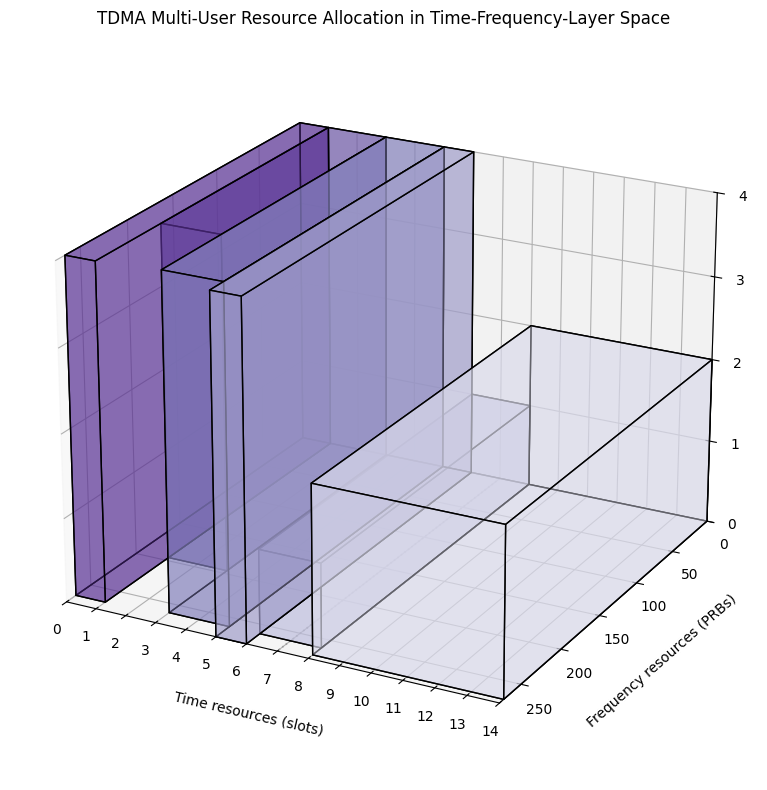

In [13]:
# ============================================================
# FINAL MULTI-USER VISUALIZATIONS
# ============================================================


# ------------------------------------------------------------
# Use the actual optimal schedule from the solver output
# ------------------------------------------------------------

schedule = [
    {
        "user": int(row["user_id"]),
        "prbs": int(row["prbs"]),
        "n_slots": int(row["n_slots"]),
        "layers": int(row["layers"]),
        "mcs": int(row["mcs"]),
        "pa_name": str(row["pa_name"]),
        "p_dc_active_w": float(row["p_dc_active_w"]),
    }
    for row in sorted(best_schedule["rows"], key=lambda item: int(item["user_id"]))
]

TOTAL_PRBS = int(max(row["prbs"] for row in schedule))
TOTAL_SLOTS = int(scheduler_results["schedule_total_slots"])
BASE_WINDOW_SLOTS = int(scheduler_results["base_window_slots"])
MAX_LAYERS = int(system_cfg["n_tx_chains"])

color_levels = np.linspace(0.25, 0.85, len(schedule))
color_levels_dark_to_light = color_levels[::-1]
user_colors = [colors.to_hex(plt.cm.Purples(level)) for level in color_levels_dark_to_light]

for row, color in zip(schedule, user_colors):
    row["color"] = color
    row["outline_color"] = color

slot_cursor = 0
for row in schedule:
    row["slot_start"] = slot_cursor
    row["slot_end"] = slot_cursor + row["n_slots"]
    slot_cursor += row["n_slots"]

unused_resource_blocks = []
for row in schedule:
    unused_prbs = TOTAL_PRBS - row["prbs"]
    if unused_prbs > 0:
        unused_resource_blocks.append(
            {
                "x": row["prbs"],
                "y": row["slot_start"],
                "width": unused_prbs,
                "height": row["n_slots"],
            }
        )

if slot_cursor < TOTAL_SLOTS:
    unused_resource_blocks.append(
        {
            "x": 0,
            "y": slot_cursor,
            "width": TOTAL_PRBS,
            "height": TOTAL_SLOTS - slot_cursor,
        }
    )

window_boundaries = list(range(BASE_WINDOW_SLOTS, TOTAL_SLOTS, BASE_WINDOW_SLOTS))


def add_time_frequency_overlays(ax):
    for x in window_boundaries:
        ax.axhline(x, color="#9e9e9e", linewidth=1.2, linestyle=":")

    for block in unused_resource_blocks:
        unused_rect = patches.Rectangle(
            (block["x"], block["y"]),
            block["width"],
            block["height"],
            fill=False,
            edgecolor="black",
            linewidth=2.4,
            linestyle="--",
        )
        ax.add_patch(unused_rect)
    for row in sorted(schedule, key=lambda item: int(item["user"]), reverse=True):
        rect = patches.Rectangle(
            (0, row["slot_start"]),
            row["prbs"],
            row["n_slots"],
            fill=False,
            edgecolor=row["outline_color"],
            linewidth=3.0,
        )
        ax.add_patch(rect)

    legend_handles = [
        patches.Patch(
            facecolor="none",
            edgecolor=row["outline_color"],
            linewidth=3.0,
            label=f"User {row['user']} allocation",
        )
        for row in schedule
    ]
    legend_handles.append(
        patches.Patch(
            facecolor="none",
            edgecolor="black",
            linewidth=2.4,
            linestyle="--",
            label="Unused resources",
        )
    )
    if window_boundaries:
        legend_handles.append(
            patches.Patch(
                facecolor="none",
                edgecolor="#9e9e9e",
                linewidth=1.2,
                linestyle=":",
                label="Window boundary",
            )
        )
    ax.legend(handles=legend_handles, loc="upper left", bbox_to_anchor=(1.21, 1.0), frameon=True)


fig = plt.figure(figsize=(13, 8))
ax = fig.add_subplot(111, projection="3d")


def cuboid(ax, x, y, z, dx, dy, dz, color):
    v = np.array([
        [x, y, z],
        [x + dx, y, z],
        [x + dx, y + dy, z],
        [x, y + dy, z],
        [x, y, z + dz],
        [x + dx, y, z + dz],
        [x + dx, y + dy, z + dz],
        [x, y + dy, z + dz],
    ])

    faces = [
        [v[i] for i in [0, 1, 2, 3]],
        [v[i] for i in [4, 5, 6, 7]],
        [v[i] for i in [0, 1, 5, 4]],
        [v[i] for i in [2, 3, 7, 6]],
        [v[i] for i in [1, 2, 6, 5]],
        [v[i] for i in [0, 3, 7, 4]],
    ]

    poly = Poly3DCollection(
        faces,
        facecolors=color,
        edgecolor="black",
        alpha=0.45,
    )
    ax.add_collection3d(poly)


for row in schedule:
    cuboid(
        ax,
        row["slot_start"],
        0,
        0,
        row["n_slots"],
        row["prbs"],
        row["layers"],
        row["color"],
    )

for x in window_boundaries:
    ax.plot([x, x], [0, TOTAL_PRBS], [0, 0], color="#9e9e9e", linestyle=":", linewidth=1.2)

ax.set_xlabel("Time resources (slots)", labelpad=12)
ax.set_ylabel("Frequency resources (PRBs)", labelpad=14)
ax.zaxis.set_rotate_label(False)
ax.set_zlabel("Spatial layers", rotation=90, labelpad=18)

ax.set_xlim(0, TOTAL_SLOTS)
ax.set_ylim(TOTAL_PRBS, 0)
ax.set_zlim(0, MAX_LAYERS)
ax.set_xticks(np.arange(0, TOTAL_SLOTS + 1, 1))
ax.set_yticks(np.arange(0, TOTAL_PRBS + 1, 50))
ax.set_zticks(np.arange(0, MAX_LAYERS + 1, 1))
ax.set_title("TDMA Multi-User Resource Allocation in Time-Frequency-Layer Space")
ax.view_init(elev=22, azim=-62)
plt.tight_layout()
plt.show()


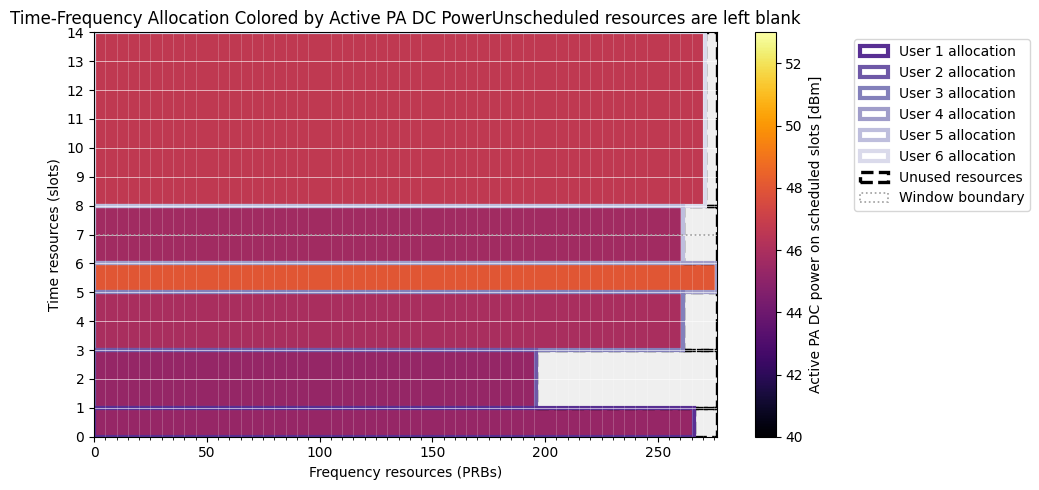

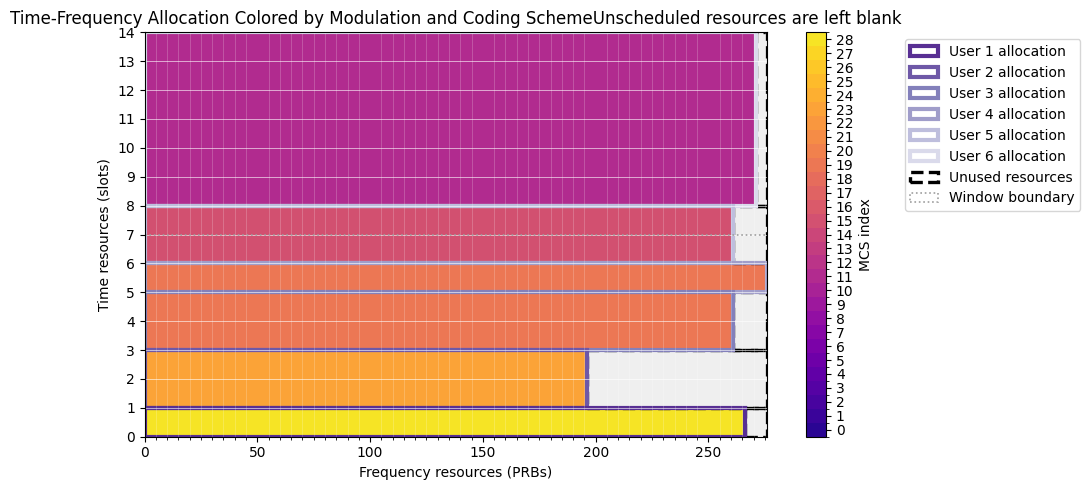

In [14]:
# ============================================================
# 2) POWER HEATMAP (ACTIVE POWER ON SCHEDULED SLOTS)
# ============================================================

power_slot_grid_w = np.full((TOTAL_SLOTS, TOTAL_PRBS), np.nan)

for row in schedule:
    power_slot_grid_w[
        row["slot_start"]:row["slot_end"],
        :row["prbs"],
    ] = row["p_dc_active_w"]

power_slot_grid_dbm = 10.0 * np.log10(power_slot_grid_w * 1e3)
active_power_dbm = power_slot_grid_dbm[np.isfinite(power_slot_grid_dbm)]

power_cmap = plt.cm.inferno.copy()
power_cmap.set_bad(color="#efefef")

vmin = float(np.floor(active_power_dbm.min()) - 5)
vmax = float(np.ceil(active_power_dbm.max()) + 5)
if np.isclose(vmin, vmax):
    vmax = vmin + 1.0

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    power_slot_grid_dbm,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=power_cmap,
    extent=(0, TOTAL_PRBS, 0, TOTAL_SLOTS),
    vmin=vmin,
    vmax=vmax,
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Active PA DC power on scheduled slots [dBm]")

ax.set_xlabel("Frequency resources (PRBs)")
ax.set_ylabel("Time resources (slots)")
ax.set_title(
    "Time-Frequency Allocation Colored by Active PA DC Power"
    "Unscheduled resources are left blank"
)

add_time_frequency_overlays(ax)

ax.set_xticks(np.arange(0, TOTAL_PRBS + 1, 50))
ax.set_xticks(np.arange(0, TOTAL_PRBS + 1, 5), minor=True)
ax.set_yticks(np.arange(0, TOTAL_SLOTS + 1, 1))
ax.grid(which="minor", axis="x", linewidth=0.4, color="white", alpha=0.35)
ax.grid(which="major", axis="y", linewidth=0.7, color="white", alpha=0.6)

plt.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()


# ============================================================
# 3) MCS HEATMAP
# ============================================================

mcs_grid = np.full((TOTAL_SLOTS, TOTAL_PRBS), np.nan)

for row in schedule:
    mcs_grid[
        row["slot_start"]:row["slot_end"],
        :row["prbs"],
    ] = row["mcs"]

mcs_levels = np.arange(0, 29)
mcs_cmap = colors.ListedColormap(plt.cm.plasma(np.linspace(0.05, 0.95, len(mcs_levels))))
mcs_cmap.set_bad(color="#efefef")
mcs_norm = colors.BoundaryNorm(np.arange(-0.5, 29.5, 1.0), mcs_cmap.N)

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(
    mcs_grid,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap=mcs_cmap,
    norm=mcs_norm,
    extent=(0, TOTAL_PRBS, 0, TOTAL_SLOTS),
)

cbar = plt.colorbar(im, ax=ax)
cbar.set_ticks(mcs_levels)
cbar.set_label("MCS index")

ax.set_xlabel("Frequency resources (PRBs)")
ax.set_ylabel("Time resources (slots)")
ax.set_title(
    "Time-Frequency Allocation Colored by Modulation and Coding Scheme"
    "Unscheduled resources are left blank"
)

add_time_frequency_overlays(ax)

ax.set_xticks(np.arange(0, TOTAL_PRBS + 1, 50))
ax.set_xticks(np.arange(0, TOTAL_PRBS + 1, 5), minor=True)
ax.set_yticks(np.arange(0, TOTAL_SLOTS + 1, 1))
ax.grid(which="minor", axis="x", linewidth=0.4, color="white", alpha=0.35)
ax.grid(which="major", axis="y", linewidth=0.7, color="white", alpha=0.6)

plt.tight_layout(rect=(0, 0, 0.84, 1))
plt.show()


## 14. Validation


In [15]:
sanity_scenarios = {
    "identical_users": [
        dict(user_id=0, distance_m=150.0, rate_target_bps=30e6),
        dict(user_id=1, distance_m=150.0, rate_target_bps=30e6),
    ],
    "near_far": [
        dict(user_id=0, distance_m=100.0, rate_target_bps=20e6),
        dict(user_id=1, distance_m=200.0, rate_target_bps=50e6),
    ],
    "high_low_rate": [
        dict(user_id=0, distance_m=150.0, rate_target_bps=50e6),
        dict(user_id=1, distance_m=150.0, rate_target_bps=20e6),
    ],
    "three_user_smoke": [
        dict(user_id=0, distance_m=100.0, rate_target_bps=30e6),
        dict(user_id=1, distance_m=150.0, rate_target_bps=40e6),
        dict(user_id=2, distance_m=200.0, rate_target_bps=50e6),
    ],
}


def extract_best_alphas(best_schedule):
    return {
        int(row["user_id"]): float(row_active_frame_share(row))
        for row in best_schedule["rows"]
    }


def enumerate_two_user_joint_schedules_exhaustive(
    user_feasible_sets,
    total_slots,
    frame_total_slots,
    pa_catalog,
    n_tx_chains,
    switch_policy,
):
    """Reference exhaustive search used only for two-user regression validation."""
    user_order = sorted(user_feasible_sets.keys())
    user0_id, user1_id = user_order
    rows0 = user_feasible_sets[user0_id].to_dict("records")
    rows1 = user_feasible_sets[user1_id].to_dict("records")

    candidate_rows = []
    best_rank = (np.inf, np.inf, np.inf)
    best_schedule_local = None
    for row0 in rows0:
        for row1 in rows1:
            slot_total = int(row0["n_slots"] + row1["n_slots"])
            if slot_total > int(total_slots):
                continue

            schedule_result = evaluate_schedule_rows(
                selected_rows=[row0, row1],
                total_slots=total_slots,
                frame_total_slots=frame_total_slots,
                pa_catalog=pa_catalog,
                n_tx_chains=n_tx_chains,
                switch_policy=switch_policy,
            )
            candidate_rows.append(
                {
                    "schedule_id": int(len(candidate_rows) + 1),
                    "slot_total": int(schedule_result["slot_total"]),
                    "alpha_total": float(schedule_result["alpha_total"]),
                    "alpha_total_frame": float(schedule_result["alpha_total_frame"]),
                    "unused_slots": int(schedule_result["unused_slots"]),
                    "unused_time": float(schedule_result["unused_time"]),
                    "total_rate_bps": float(schedule_result["total_rate_bps"]),
                    "schedule_p_dc_total_avg_frame_w": float(schedule_result["schedule_p_dc_total_avg_frame_w"]),
                    "schedule_p_rf_out_total_avg_frame_w": float(schedule_result["schedule_p_rf_out_total_avg_frame_w"]),
                }
            )

            candidate_rank = _schedule_rank(
                schedule_result["schedule_p_dc_total_avg_frame_w"],
                slot_total,
                schedule_result["total_rate_bps"],
            )
            if candidate_rank < best_rank:
                best_rank = candidate_rank
                best_schedule_local = schedule_result

    joint_df_exhaustive = pd.DataFrame(candidate_rows)
    if not joint_df_exhaustive.empty:
        joint_df_exhaustive = joint_df_exhaustive.sort_values(
            ["schedule_p_dc_total_avg_frame_w", "slot_total", "total_rate_bps"],
            ascending=[True, True, False],
        ).reset_index(drop=True)

    return {
        "joint_df": joint_df_exhaustive,
        "best_schedule": best_schedule_local,
    }


def validate_scheduler_result(result, scenario_users):
    target_rate_map = {
        int(user["user_id"]): float(user["rate_target_bps"])
        for user in scenario_users
    }
    best_rows = result["best_schedule"]["rows"]
    alpha_sum_on_window = float(sum(float(row_active_on_window_share(row)) for row in best_rows))
    alpha_sum_frame = float(sum(float(row_active_frame_share(row)) for row in best_rows))
    schedule_p_dc_sum = float(sum(float(pa_row["pa_p_dc_total_avg_frame_w"]) for pa_row in result["best_schedule"]["pa_summaries"]))
    rf_output_power_sum = float(sum(float(row_p_rf_out_avg_frame_w(row)) for row in best_rows))
    rate_sum = float(sum(float(row_rate_avg_frame_bps(row)) for row in best_rows))
    returned_user_ids = {int(row["user_id"]) for row in best_rows}
    expected_user_ids = set(target_rate_map)

    return {
        "meets_rate_targets": all(
            float(row_rate_avg_frame_bps(row)) + 1e-9
            >= target_rate_map[int(row["user_id"])]
            for row in best_rows
        ),
        "alpha_sum_on_window_within_budget": alpha_sum_on_window <= 1.0 + 1e-12,
        "alpha_sum_frame_within_budget": alpha_sum_frame <= (
            float(result["schedule_total_slots"]) / float(result["schedule_total_frame_slots"])
        ) + 1e-12,
        "schedule_p_dc_consistent": np.isclose(
            schedule_p_dc_sum,
            float(result["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
        ),
        "schedule_p_rf_consistent": np.isclose(
            rf_output_power_sum,
            float(result["best_schedule"]["schedule_p_rf_out_total_avg_frame_w"]),
        ),
        "total_rate_consistent": np.isclose(rate_sum, float(result["best_schedule"]["total_rate_bps"])),
        "user_coverage_complete": returned_user_ids == expected_user_ids,
    }


def run_scenario_scheduler(scenario_users, switch_policy):
    scenario_active_tables = {}
    for user in scenario_users:
        scenario_active_tables[int(user["user_id"])] = enumerate_user_active_configs(user, system_cfg, pa_catalog)

    original_active_tables = active_config_tables.copy()
    active_config_tables.clear()
    active_config_tables.update(scenario_active_tables)
    try:
        return run_multi_user_scheduler(
            users=scenario_users,
            system_cfg=system_cfg,
            slot_allocation_space=slot_allocation_space,
            pa_catalog=pa_catalog,
            switch_policy=switch_policy,
            max_configs_per_user=max_configs_per_user,
        )
    finally:
        active_config_tables.clear()
        active_config_tables.update(original_active_tables)


def compare_switch_policies(scenario_name, scenario_users):
    rows = []
    for policy in [PASwitchPolicy.STANDBY, PASwitchPolicy.HARD_OFF]:
        result = run_scenario_scheduler(scenario_users, switch_policy=policy)
        rows.append(
            {
                "scenario": scenario_name,
                "switch_policy": policy.value,
                "schedule_windows": int(result["schedule_windows"]),
                "schedule_p_dc_total_avg_frame_w": float(result["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
                "schedule_p_rf_out_total_avg_frame_w": float(result["best_schedule"]["schedule_p_rf_out_total_avg_frame_w"]),
                "total_rate_mbps": float(result["best_schedule"]["total_rate_bps"]) / 1e6,
            }
        )
    return pd.DataFrame(rows)


validation_rows = []
comparison_rows = []
for scenario_name, scenario_users in sanity_scenarios.items():
    result = run_scenario_scheduler(scenario_users, switch_policy=SWITCH_POLICY)
    checks = validate_scheduler_result(result, scenario_users)
    validation_row = {
        "scenario": scenario_name,
        **checks,
    }

    if len(scenario_users) == 2:
        exhaustive = enumerate_two_user_joint_schedules_exhaustive(
            user_feasible_sets=result["user_feasible_sets"],
            total_slots=result["schedule_total_slots"],
            frame_total_slots=result["schedule_total_frame_slots"],
            pa_catalog=pa_catalog,
            n_tx_chains=int(system_cfg["n_tx_chains"]),
            switch_policy=SWITCH_POLICY,
        )
        validation_row["matches_exhaustive_objective"] = np.isclose(
            float(exhaustive["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
            float(result["best_schedule"]["schedule_p_dc_total_avg_frame_w"]),
        )

    validation_rows.append(validation_row)
    comparison_rows.append(compare_switch_policies(scenario_name, scenario_users))

validation_df = pd.DataFrame(validation_rows)
policy_comparison_df = pd.concat(comparison_rows, ignore_index=True)

display(validation_df)
display(policy_comparison_df)


,scenario,meets_rate_targets,alpha_sum_on_window_within_budget,alpha_sum_frame_within_budget,schedule_p_dc_consistent,schedule_p_rf_consistent,total_rate_consistent,user_coverage_complete,matches_exhaustive_objective
0,identical_users,True,True,True,True,True,True,True,True
1,near_far,True,True,True,True,True,True,True,True
2,high_low_rate,True,True,True,True,True,True,True,True
3,three_user_smoke,True,True,True,True,True,True,True,NaN


,scenario,switch_policy,schedule_windows,schedule_p_dc_total_avg_frame_w,schedule_p_rf_out_total_avg_frame_w,total_rate_mbps
0,identical_users,standby,1,2.915469,0.109794,60.292253
1,identical_users,hard_off,1,0.863718,0.109794,60.292253
2,near_far,standby,1,2.973211,0.141931,79.617830
3,near_far,hard_off,1,1.379418,0.201539,79.334323
4,high_low_rate,standby,1,2.906427,0.115674,76.265846
5,high_low_rate,hard_off,1,0.996626,0.163557,70.782077
6,three_user_smoke,standby,1,3.258479,0.234491,137.345390
7,three_user_smoke,hard_off,1,1.960797,0.304644,120.994286
